# Part 2: Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
df_eda= pd.read_csv('../Data/smartwatch_eda_completed.csv')
df_fe=df_eda.copy()

In [3]:
def extract_apple_series_pro(title):
    title = str(title).upper()
    if 'ULTRA 3' in title: return 'ULTRA 3'
    if 'ULTRA 2' in title: return 'ULTRA 2'
    if 'ULTRA' in title: return 'ULTRA'
    if 'SE' in title: return 'SE'
    if 'HERMES' in title: return 'EDITION'
    match = re.search(r'SERIES\s*(\d+)\b', title)
    if match:
        return match.group(1)
        
    return 'Other'

df_fe['apple_series'] = df_fe.apply(lambda x: extract_apple_series_pro(x['title']) if x['brand'] == 'Apple' else 'Non-Apple', axis=1)

In [4]:
print(df_fe['apple_series'].value_counts())

apple_series
Non-Apple    1236
SE           1159
ULTRA 2       561
ULTRA 3       337
ULTRA         241
Other          65
EDITION         6
Name: count, dtype: int64


#### Ta thấy số lượng Other chỉ còn 65, ta sẽ xem xét cái Title sẽ chứa gì

In [5]:
print(df_fe[df_fe['apple_series'] == 'Other']['title'].head(20))

20            MacBook, Watch, iPad and pro pencil  Bundle
175     Apple Watch 10 46mm Natural Milane Loop - Appl...
434     24K Gold Plated Stainless Steel Apple Watch 45...
498         Apple Watch 42mm Gold Titanium GPS + Cellular
518     24K Gold Plated 42MM Apple Watch Gen 1 24K Gol...
645     24K Gold 42MM Apple Watch with Gold Links Band...
723     Apple Watch Hermès 45mm Gold/Etoupe - Unopened...
763                 Apple Watch - Pre-Owned, No Scratches
772     Apple Watch Hermès S5 44mm SS LTE – Leather (B...
812                          Apple Watch 11 Titanium 46mm
844     APPLE Model number: MWQJ2J/A APPLE WATCH Labar...
871           24K Gold 42MM Apple Watch And Gold Neckless
883     42MM Apple Watch 24K Gold Plated W/Black and B...
907     24K Gold 42MM Apple Watch with Leather Etoupe ...
964     24K Gold 42MM Apple Watch Gen 1 With Double To...
983     Apple Watch 3 49mm BLACK TITANIUM BLACK GPS+CE...
988     Apple Watch 3 49mm natural titanium ocean band...
1013    Apple 

#### Ta thấy có một vài số liệu gây nhiễu như Macbook, Ipad ở dòng 20 hay thế hệ đầu Gen 1 ở dòng 518 và 964

In [6]:
def extract_apple_series_final(title):
    title = str(title).upper()
    
    if 'ULTRA 3' in title: return 'ULTRA 3'
    if 'ULTRA 2' in title: return 'ULTRA 2'
    if 'ULTRA' in title: return 'ULTRA'
    if 'SE' in title: return 'SE'
    if 'HERMES' in title or 'EDITION' in title: return 'EDITION'
    if 'GEN 1' in title: return '1'
    
    match = re.search(r'(?:SERIES|WATCH)\s*([1-9]|10|11)\b', title)
    if match:
        return match.group(1)
        
    return 'Other'

keywords_to_remove = ['BUNDLE', 'LOT', 'MACBOOK', 'IPAD', 'IPHONE', 'AIRPODS']
df_fe = df_fe[~df_fe['title'].str.upper().str.contains('|'.join(keywords_to_remove))]

In [7]:
def extract_apple_series_super_final(title):
    title = str(title).upper()
    if 'ULTRA 3' in title: return 'ULTRA 3'
    if 'ULTRA 2' in title: return 'ULTRA 2'
    if 'ULTRA' in title: return 'ULTRA'
    if 'SE' in title: return 'SE'
    if 'HERMES' in title or 'EDITION' in title: return 'EDITION'
    
    if 'GEN 1' in title or '1ST GEN' in title: return '1'
    match = re.search(r'(?:SERIES|WATCH)\s*([1-9]|10|11)\b', title)
    if match:
        return match.group(1)
        
    return 'Other'

df_fe['apple_series'] = df_fe.apply(lambda x: extract_apple_series_super_final(x['title']) if x['brand'] == 'Apple' else 'Non-Apple', axis=1)

In [8]:
print(df_fe['apple_series'].value_counts())

apple_series
Non-Apple    1207
SE           1132
ULTRA 2       561
ULTRA 3       335
ULTRA         235
Other          49
EDITION         7
1               6
3               3
10              1
11              1
8               1
9               1
Name: count, dtype: int64


In [9]:
apple_others = df_fe[(df_fe['brand'] == 'Apple') & (df_fe['apple_series'] == 'Other')]
print(f"Số lượng Apple Watch chưa phân loại được: {len(apple_others)}")
print(apple_others['title'].head(10))

Số lượng Apple Watch chưa phân loại được: 49
434     24K Gold Plated Stainless Steel Apple Watch 45...
498         Apple Watch 42mm Gold Titanium GPS + Cellular
645     24K Gold 42MM Apple Watch with Gold Links Band...
723     Apple Watch Hermès 45mm Gold/Etoupe - Unopened...
763                 Apple Watch - Pre-Owned, No Scratches
772     Apple Watch Hermès S5 44mm SS LTE – Leather (B...
844     APPLE Model number: MWQJ2J/A APPLE WATCH Labar...
871           24K Gold 42MM Apple Watch And Gold Neckless
907     24K Gold 42MM Apple Watch with Leather Etoupe ...
1013    Apple Watch Hermès 41mm Silver Brand New Condi...
Name: title, dtype: object


#### Do 49 sản phẩm other so với 3607 là rất nhỏ nên ta không cần dùng regex để tách ra tiếp

In [10]:
def extract_material(title):
    title = str(title).upper()
    if 'GOLD' in title and 'TITANIUM' in title: return 'Gold_Titanium'
    if 'TITANIUM' in title: return 'Titanium'
    if 'GOLD' in title: return 'Gold'
    if 'CERAMIC' in title: return 'Ceramic'

    if 'STAINLESS' in title or 'STEEL' in title: return 'StainLess_Steel'

    if 'ALUMINIUM' in title or 'ALUMIUM' in title: return 'Aluminum'

    return 'Standard'


#### Một số title có chất liệu của sản phẩm, khả năng cao là chất liệu sẽ ảnh hưởng đến giá tiền:
* Ta cần trích title để lấy material của sản phẩm

In [11]:
df_fe['material'] = df_fe['title'].apply(extract_material)
print(df_fe.groupby('material')['price'].median().sort_values(ascending=False))



material
Gold               699.0
Gold_Titanium      627.5
Titanium           580.0
Ceramic            550.0
Standard           529.0
StainLess_Steel    500.0
Aluminum           450.0
Name: price, dtype: float64


#### Ta thấy giá của smartwatch với chất liệu cao cấp như Gold hay Titanium thì thường có giá tiền cao hơn so với các chất liệu tiêu chuẩn hay Aluminum

In [12]:
df_fe['material'].value_counts()

material
Standard           1806
Titanium           1147
Gold                310
StainLess_Steel     156
Aluminum             71
Gold_Titanium        40
Ceramic               9
Name: count, dtype: int64

#### Ta thấy có con số cho vật liệu cao cấp như Titanium là 1147 trong 3607 hay trong Gold là 310 trong 3607

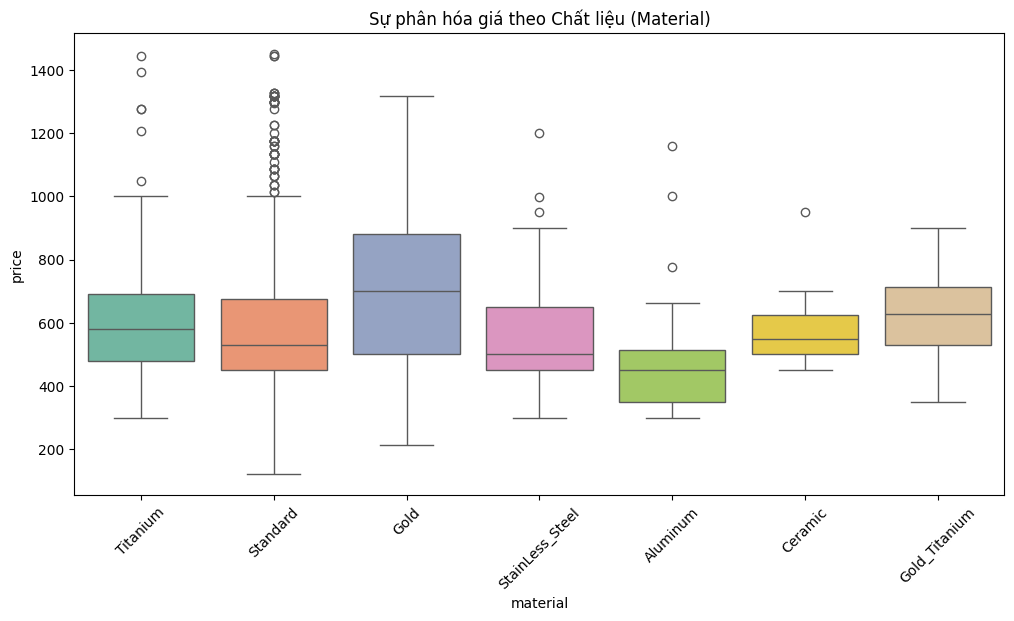

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_fe, x='material', y='price', hue='material', palette='Set2', legend=False);
plt.title('Sự phân hóa giá theo Chất liệu (Material)')
plt.xticks(rotation=45)
plt.show()

In [14]:
print(df_fe[(df_fe['material'] == 'Standard') & (df_fe['price'] > 1000)]['title'].head(10))

3                    garmin tactix 7 amoled edition BNIB
83     Samsung Galaxy Watch3 (45mm) 4G Mystic Black 8...
84     Samsung Galaxy Watch3 (45mm) 4G Mystic Bronze ...
86     Samsung Galaxy Watch 3 (41mm) 4G Mystic Silver...
170    Samsung Galaxy Watch Ultra 47mm 4G LTE + Bluet...
171    Samsung Galaxy Watch Ultra 47mm 4G LTE + Bluet...
181    Garmin Venu 2S Wifi + Bluetooth Slate & Graphi...
182    Garmin Venu 2S Wifi + Bluetooth Mist Grey & Si...
183    Garmin Venu 2 Wifi + Bluetooth Silver & Blue S...
185    Samsung Galaxy Watch Ultra (2025) 47mm 4G + Bl...
Name: title, dtype: object


#### Ta thấy trong phân loại standard có những sản phẩm không có chất liệu nhưng lại có các dòng Ultra:
* Các dòng cao cấp như Ultra khiến cho cột Standard có nhiều sản phẩm ngoại lai khi giá cao hơn rất nhiều 
* Vì vậy, ta cần tạo một cột mới để lưu những phân loại cao cấp này

In [15]:
def extract_model_tier(title):
    title = str(title).upper()
    if any(kw in title for kw in ['ULTRA', 'TACTIX', 'MARQ', 'EPIX', 'HERMES', 'EDITION']):
        return 'Premium_Tier'
    if any(kw in title for kw in ['PRO', 'CLASSIC', 'SAPPHIRE', 'SOLAR', 'Fenix']):
        return 'Advanced_Tier'
    return 'Basic_Tier'
df_fe['model_tier'] = df_fe['title'].apply(extract_model_tier)


In [16]:
df_fe['model_tier'].value_counts()

model_tier
Basic_Tier       1755
Premium_Tier     1480
Advanced_Tier     304
Name: count, dtype: int64

In [17]:
print(df_fe.groupby('model_tier')['price'].median().sort_values(ascending=False))

model_tier
Premium_Tier     594.00
Advanced_Tier    547.49
Basic_Tier       525.99
Name: price, dtype: float64


In [18]:
df_fe['is_cellular'] = df_fe['title'].str.contains('LTE|4G|CELLULAR|SIM', case=False).astype(int)

pivot_check = df_fe.groupby(['model_tier', 'is_cellular'])['price'].median().unstack()
print(pivot_check)

is_cellular          0        1
model_tier                     
Advanced_Tier  554.150  494.180
Basic_Tier     525.840  529.000
Premium_Tier   599.475  569.995


#### Ta thấy có nghịch lý ở đây khi giá của việc có cellular lại thấp hơn những bản không có cellular
* Nguyên nhân có thể là ở dòng Premium đời cũ đều có tích hợp cellular nhưng do qua thời gian dài nên giá giảm xuống
* Trong khi đó những máy không có cellular lại chứa nhiều máy Basic đời mới nên giá còn rất cao

In [19]:
count_check = df_fe.groupby(['model_tier', 'is_cellular'])['price'].count().unstack()
print(count_check)

is_cellular       0    1
model_tier              
Advanced_Tier   259   45
Basic_Tier     1308  447
Premium_Tier    808  672


In [30]:
Q1 = df_fe['price'].quantile(0.25)
Q3 = df_fe['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_final_clean = df_fe[(df_fe['price'] >= lower_bound) & (df_fe['price'] <= upper_bound)]

print(f"Dữ liệu ban đầu: {len(df_fe)}")
print(f"Dữ liệu sau khi lọc: {len(df_final_clean)}")
print(f"Đã loại bỏ {len(df_fe) - len(df_final_clean)} dòng outliers.")

Dữ liệu ban đầu: 3539
Dữ liệu sau khi lọc: 3481
Đã loại bỏ 58 dòng outliers.


In [21]:
print(f"Độ lệch của giá gốc: {df_fe['price'].skew()}")
print(f"Độ lệch sau khi Log: {np.log1p(df_fe['price']).skew()}")

Độ lệch của giá gốc: 1.1668701697394939
Độ lệch sau khi Log: 0.2886021289425354


#### Nếu độ lệch của giá gốc lớn hơn 1 thì ta phải dùng Log Transform để thu nhỏ khoảng cách các Outliers

In [22]:
df_fe['price_log'] = np.log1p(df_fe['price'])

## Label Encoding

In [23]:

tier_mapping = {'Basic_Tier': 1, 'Advanced_Tier': 2, 'Premium_Tier': 3}
df_fe['model_tier_encoded'] = df_fe['model_tier'].map(tier_mapping)

series_mapping ={
    '1':1, '2':2, '3':3, '4':4, '5':5, '6':6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11,
    'SE': 7,     
    'ULTRA': 10,   
    'ULTRA 2': 11, 'ULTRA 3':12,
    'EDITION':7, 'Non-Apple':-1, 
    'Other': 0 }
df_fe['apple_series_rank']=df_fe['apple_series'].map(series_mapping)

condition_mapping = {
    'New': 3,
    'Open Box': 2.5, 
    'Refurbished': 2,
    'Used': 1,
    'Broken/Other': 0
}
df_fe['condition_encoded'] = df_fe['condition'].map(condition_mapping)



In [24]:
print("Số lượng dòng bị thiếu (Null):", df_fe['apple_series_rank'].isnull().sum())

Số lượng dòng bị thiếu (Null): 0


#### Kiểm tra thì thấy không còn dữ liệu nào bị thiếu

In [25]:
df_final = pd.get_dummies(df_fe, columns=['brand', 'material', 'Country'], drop_first=True)

#### Phần còn lại là brand và material ta sẽ chuyển sang One-Hot Encoding với các biến không có thứ tự

In [26]:

cols_to_drop = ['title', 'brand', 'material', 'model_tier', 'apple_series', 'condition', 'case_size_regex', 'Seller_ID']

df_final_clean = df_final.drop(columns=[c for c in cols_to_drop if c in df_final.columns])

print("Danh sách các cột sẽ đưa vào train model:")
print(df_final_clean.columns.tolist())

Danh sách các cột sẽ đưa vào train model:
['Case_Size_mm', 'price', 'Is_Worldwide_Shipping', 'is_cellular', 'price_log', 'model_tier_encoded', 'apple_series_rank', 'condition_encoded', 'brand_Garmin', 'brand_Samsung', 'brand_Small brand', 'material_Ceramic', 'material_Gold', 'material_Gold_Titanium', 'material_StainLess_Steel', 'material_Standard', 'material_Titanium', 'Country_Japan', 'Country_Other countries', 'Country_South Korea', 'Country_United Kingdom', 'Country_United States']


In [27]:
df_final_clean['condition_encoded'].isnull().sum()

np.int64(0)

In [28]:
df_final_clean.dtypes

Case_Size_mm                float64
price                       float64
Is_Worldwide_Shipping         int64
is_cellular                   int64
price_log                   float64
model_tier_encoded            int64
apple_series_rank             int64
condition_encoded           float64
brand_Garmin                   bool
brand_Samsung                  bool
brand_Small brand              bool
material_Ceramic               bool
material_Gold                  bool
material_Gold_Titanium         bool
material_StainLess_Steel       bool
material_Standard              bool
material_Titanium              bool
Country_Japan                  bool
Country_Other countries        bool
Country_South Korea            bool
Country_United Kingdom         bool
Country_United States          bool
dtype: object

#### Ta phải đảm bảo tất cả dữ liệu phải về dạng int, float để khi qua machine learning thì máy mới có thể học được

In [29]:
df_final_clean.to_csv('smartwatch_data_ready_for_ml.csv', index=False)

## ✅ Tổng kết giai đoạn Feature Engineering
- **Dữ liệu thô:** 10 cột ban đầu (nhiều cột Object/Text).
- **Các tính năng mới đã tạo:**
    - `is_cellular`: Tách từ tiêu đề (LTE/4G).
    - `apple_series_rank`: Mã hóa thứ tự các đời máy.
    - `model_tier_encoded`: Phân cấp dòng máy (Basic, Advanced, Premium).
    - `condition_encoded`: Mã hóa tình trạng máy (New, Used, ...).
    - `price_log`: Chuẩn hóa cột giá bằng Log Transform.
- **Encoding:** Đã thực hiện One-Hot cho `brand`, `material`, `Country`.
- **Dọn dẹp:** Loại bỏ các cột định danh không cần thiết (Seller_ID, title, ...).
- **Kết quả:** File dữ liệu cuối cùng sạch 100% (không có Null), tất cả đều ở dạng số.